# Proyecto: Series temporales - Predicción de ventas (ARIMA)

## Objetivo
A partir de un histórico de ventas con fechas, construiremos una serie temporal, analizaremos sus características (tensor, tendencia, estacionariedad y ruido) y entrenaremos un modelo **ARIMA** para predecir las ventas futuras. Finalmente, evaluaremos el rendimiento y guardaremos el modelo entrenado.


In [232]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


## Paso 1: Carga del conjunto de datos

Cargamos el CSV y revisamos estructura, columnas y valores nulos para entender qué representa cada variable.


In [233]:
path = "../data/raw/sales.csv"

df = pd.read_csv(path)

df.head()


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [234]:
# informacion general

df.info(), df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


(None,
              sales
 count   366.000000
 mean    524.963968
 std     275.089698
 min      53.803211
 25%     290.186822
 50%     520.699468
 75%     763.289263
 max    1000.482785)

## Paso 2: Construcción de la serie temporal

Convertimos la columna **date** a tipo fecha, la usamos como índice y ordenamos cronológicamente.  
También verificamos que no falten fechas (muy importante en series temporales).



In [235]:
##Convertir fecha, indexar y ordenar
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

df.head()


,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [236]:
##Comprobar frecuencia y fechas faltantes
# Inferir frecuencia aproximada (si se puede)
freq = pd.infer_freq(df.index)
freq


'D'

In [237]:
# Crear un rango completo diario y ver si faltan fechas
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = full_range.difference(df.index)

len(missing_dates), missing_dates[:5]


(0, DatetimeIndex([], dtype='datetime64[ns]', freq='D'))

In [238]:
##Ajustar a frecuencia diaria y rellenar huecos
# Forzamos a frecuencia diaria (D) y rellenamos posibles huecos
ts = df["sales"].asfreq("D")

# Si hubiera nulos por huecos, interpolamos linealmente
ts = ts.interpolate()

ts.head(), ts.isna().sum()


(date
 2022-09-03 17:10:08.079328    55.292157
 2022-09-04 17:10:08.079328    53.803211
 2022-09-05 17:10:08.079328    58.141693
 2022-09-06 17:10:08.079328    64.530899
 2022-09-07 17:10:08.079328    66.013633
 Freq: D, Name: sales, dtype: float64,
 np.int64(0))

### Visualización de la serie temporal

Representamos las ventas a lo largo del tiempo para detectar tendencia, variabilidad y posibles patrones.


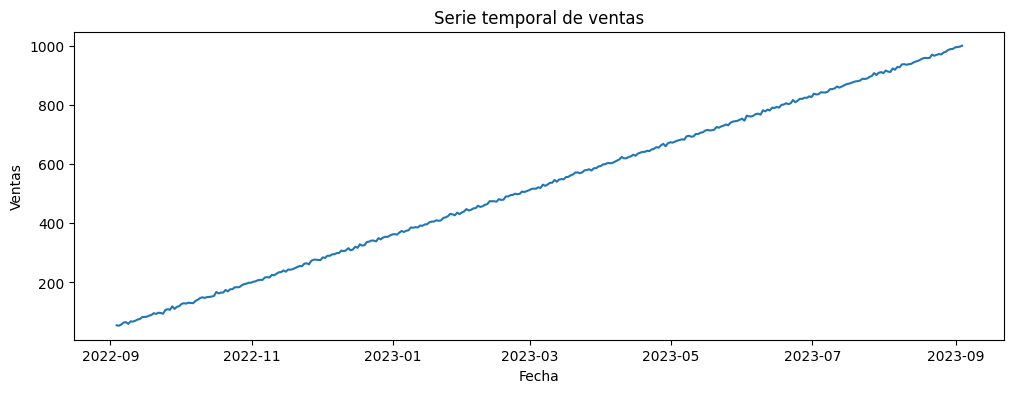

In [239]:
plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title("Serie temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()


## Análisis requerido

### 1) ¿Cuál es el tensor de la serie temporal?

El **tensor** es la unidad mínima de tiempo para la que tenemos un dato.  
En este dataset, las observaciones están registradas **día a día**, por lo que el tensor es **diario (1 día)**.


### 2) ¿Cuál es la tendencia?

La tendencia se observa como un crecimiento o decrecimiento a largo plazo.  
En la gráfica se aprecia una **tendencia creciente** (aumenta el nivel medio de ventas conforme avanza el tiempo).


### 3) ¿Es estacionaria?

Una serie es **estacionaria** si sus propiedades estadísticas (media y varianza) se mantienen aproximadamente constantes con el tiempo.  
Como visualmente hay tendencia, **probablemente no sea estacionaria**.  
Lo comprobamos con el test ADF (Augmented Dickey-Fuller):

- **H0 (hipótesis nula):** la serie NO es estacionaria  
- Si `p-value < 0.05` rechazamos H0 ⇒ estacionaria  
- Si `p-value >= 0.05` no rechazamos H0 ⇒ no estacionaria


In [240]:
result = adfuller(ts.dropna())

adf_stat = result[0]
p_value = result[1]

print("ADF Statistic:", adf_stat)
print("p-value:", p_value)


ADF Statistic: 0.545414193706378
p-value: 0.9861899815311064


**Interpretación:**

- Si el `p-value` es mayor que 0.05, concluimos que la serie **no es estacionaria** (lo normal en series de ventas con tendencia).
- Si fuera menor que 0.05, podría considerarse estacionaria.

En nuestro caso, el resultado del test confirma la conclusión observada visualmente.


### 4) ¿Existe variabilidad o presencia de ruido?

Sí. En series reales es normal que exista **ruido**, es decir, fluctuaciones diarias que no siguen exactamente la tendencia.  
Esto se observa en las oscilaciones alrededor del crecimiento general.


## Descomposición de la serie (opcional recomendado)

La descomposición separa la serie en:
- tendencia
- estacionalidad (si existe)
- residuo (ruido)

Como el tensor es diario, podemos probar una estacionalidad semanal aproximada (period=7).


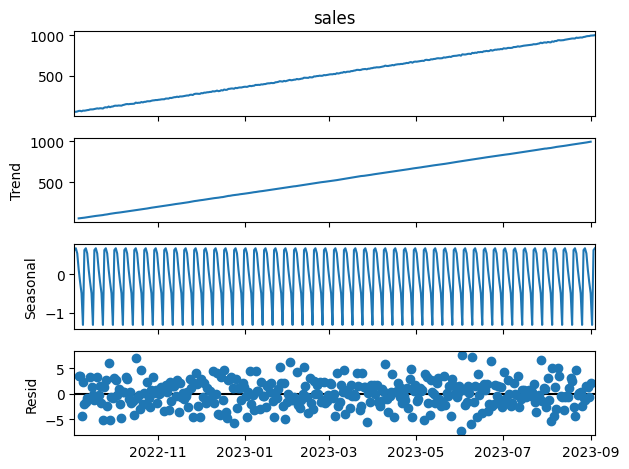

In [241]:
##Descomposición de la serie temporal
decomp = seasonal_decompose(ts, model="additive", period=7)
decomp.plot()
plt.show()


## Paso 3: Entrenar un ARIMA

Dividimos la serie en:
- **train:** datos históricos para entrenar
- **test:** últimos valores para evaluar predicción

Usamos como test los últimos 30 días (periodo reciente).


In [242]:
test_size = 30
train = ts.iloc[:-test_size]
test  = ts.iloc[-test_size:]

train.shape, test.shape


((336,), (30,))

### Búsqueda de parámetros (p, d, q) MEJORES PARAMETROS

Probamos distintas combinaciones y seleccionamos la que tenga menor AIC (criterio de información).  
Esto ayuda a encontrar un ARIMA razonable sin hacerlo a mano.


In [243]:
## Grid simple por AIC
import itertools

p_values = range(0, 4)
d_values = range(0, 3)
q_values = range(0, 4)

best_aic = np.inf
best_order = None
best_model = None

for order in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit()
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = order
            best_model = fitted
    except:
        continue

best_order, best_aic


((0, 2, 3), np.float64(1702.51494997004))

Entrenamos el ARIMA final con la mejor parametrización encontrada y revisamos el resumen del modelo.


In [244]:
## Fit final y summary
final_model = ARIMA(train, order=best_order).fit()
final_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  336
Model:                 ARIMA(0, 2, 3)   Log Likelihood                -847.257
Date:                Fri, 19 Dec 2025   AIC                           1702.515
Time:                        20:28:43   BIC                           1717.760
Sample:                    09-03-2022   HQIC                          1708.593
                         - 08-04-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.0310      0.430     -4.722      0.000      -2.874      -1.188
ma.L2          1.1319      0.460      2.462      0.014       0.231       2.033
ma.L3         -0.1009      0.073     -1.385      0.166      -0.244       0.042
sigma2         8.9920      3.798      2.368      0.018       1.549      16.435
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.13
Prob(Q):                              0.93   Prob(JB):                         0.57
Heteroskedasticity (H):               0.86   Skew:                             0.07
Prob(H) (two-sided):                  0.44   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""


## Paso 4: PREDICCIÓN Y EVALUACIÓN     
Predicción con el conjunto de test

Generamos predicciones para el rango del test y comparamos:
- valores reales
- valores predichos

Luego medimos rendimiento con MAE y RMSE.


In [245]:
#predicciones
pred = final_model.predict(start=test.index[0], end=test.index[-1])
pred.head()


2023-08-05 17:10:08.079328    923.487872
2023-08-06 17:10:08.079328    926.283257
2023-08-07 17:10:08.079328    928.878258
2023-08-08 17:10:08.079328    931.473260
2023-08-09 17:10:08.079328    934.068262
Freq: D, Name: predicted_mean, dtype: float64

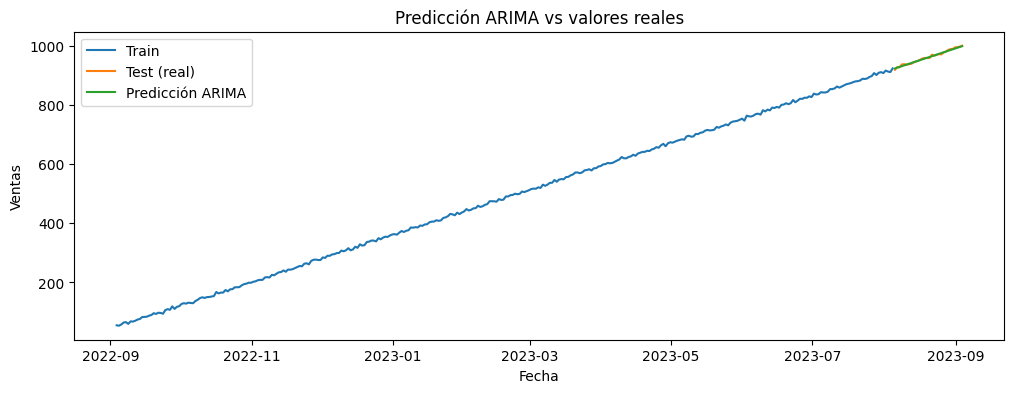

In [246]:
##Gráfico real vs predicción
plt.figure(figsize=(12,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test (real)")
plt.plot(pred, label="Predicción ARIMA")
plt.title("Predicción ARIMA vs valores reales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.show()


In [247]:
## metricas de error
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE :", mae)
print("RMSE:", rmse)



MAE : 2.0660099604512956
RMSE: 2.586314151868622


### Interpretación del rendimiento

- **MAE**: error medio absoluto (en unidades de ventas).
- **RMSE**: penaliza más los errores grandes.

Valores más bajos indican mejor ajuste.  
Además del número, es importante observar si la curva predicha sigue la tendencia de la real.


## Paso 5: Guardar el modelo

Guardamos el modelo entrenado para poder reutilizarlo sin reentrenar.


In [248]:
import os
import pickle

os.makedirs("models", exist_ok=True)

with open("models/arima_sales.pkl", "wb") as f:
    pickle.dump(final_model, f)

"Modelo guardado en models/arima_sales.pkl"


'Modelo guardado en models/arima_sales.pkl'

# Conclusiones

- El **tensor** de la serie es **diario**.
- Se observa **tendencia creciente** en las ventas.
- La serie **no es estacionaria** (confirmado con ADF), lo cual es habitual en ventas.
- Existe **ruido/variabilidad diaria**.
- Se entrenó un modelo **ARIMA** seleccionando parámetros por AIC.
- Se evaluó con MAE y RMSE comparando predicción vs valores reales.
- El modelo final se guardó para su uso posterior.
